<a href="https://colab.research.google.com/github/prajwalbiradar21/Customer-Engagement-Product-Utilization-Analytics-for-Retention-Strategy/blob/main/Customer_Engagement_%26_Product_Utilization_Analytics_for_Retention_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem Statement :

Despite having data on customer engagement and product usage, banks often lack:

• Quantitative insight into which behaviors drive retention

• Clarity on whether product depth reduces churn

• Evidence on whether high balances alone ensure loyalty

As a result, retention strategies are frequently generic and misaligned with actual customer behavior.

### Project Objectives


• Evaluate the relationship between engagement and churn

• Measure retention impact of product count and product mix

• Identify disengaged yet high-value customers

Secondary Objectives

• Support engagement-driven retention strategies

• Improve product bundling decisions

• Reduce silent churn among premium customers

### Lets Begin!
1. Know your Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.express as px
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Loading DataSet

In [2]:
df = pd.read_csv('/content/European_Bank.csv')

pd.set_option('display.max_columns',None) # display all columns
pd.set_option('display.max_rows',100)

Dataset First View

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
df.shape

(10000, 14)

In [6]:
print("Rows:", df.shape[0]) # 0 --> rows
print("Columns:", df.shape[1]) # 1 --> columns

Rows: 10000
Columns: 14


Dataset Information

In [7]:
#Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

Missing Values / Null Values

In [9]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
# Check Unique Values for each variable.

df.nunique()

,0
Year,1
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


In [12]:
# Traget Variable

percent = df['Exited'].value_counts(normalize =True) * 100
print(percent)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


What did you know about your dataset?

* The dataset contains customer-level information from a European bank.
* Each row represents a unique customer.
* The dataset consists of both numerical and categorical features that describe customer demographics, financial status, engagement behavior, and churn status.
* The dataset contains 10,000 customer records and 14 variables (including the target variable Exited).
* No missing values were found in the dataset.
* No duplicate records were present in the dataset.
* Column ('Exited') is the target variable where (*0 - customer retained*) and (*1 - customer churned*) .

### 2. Understanding Your Variables

In [13]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [14]:
df.describe(include =object)

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [15]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Dataset Description**

    Column -	Description
1. CustomerId	- Unique customer identifier
2. Surname	- Customer surname
3. CreditScore -	Customer creditworthiness
4. Geography -	France, Spain, Germany
5. Gender	- Male / Female
6. Age	- Customer age
7. Tenure	- Years with the bank
8. Balance -	Account balance
9. NumOfProducts	- Number of bank products
10. HasCrCard	- Credit card ownership
11. IsActiveMember -	Activity indicator
12. EstimatedSalary -	Estimated annual salary
13. Exited -	Churn indicator (target)

### Data Wrangling

In [16]:
df.shape

(10000, 14)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [18]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.nunique()

,0
Year,1
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


In [21]:
# Checking Customer ID Uniqueness

len(df['CustomerId'])

10000

In [22]:
df['CustomerId'].duplicated().sum()

np.int64(0)

In [23]:
#Checking Unique Values in Categorical Columns

cat_cols = ['Geography','Gender']

for col in cat_cols:
    print(df[col].value_counts())
    print('---------------------')

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
---------------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
---------------------


In [24]:
# Checking Binary Variables Consistency

binary_cols = ['HasCrCard','IsActiveMember','Exited']

for col in binary_cols:
  print(df[col].value_counts(normalize=True)*100)
  print('--------------------')

HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64
--------------------
IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64
--------------------
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64
--------------------


In [25]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [26]:
# Check Class Imbalance : Since Exited is our target:

df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [27]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


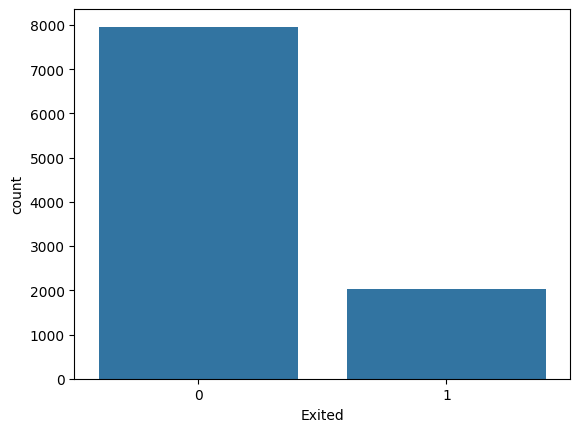

In [28]:
## Visualisation

sns.countplot(x='Exited', data=df)
plt.show()

### Exploratory Data Analysis (EDA)

### Univariate Analysis

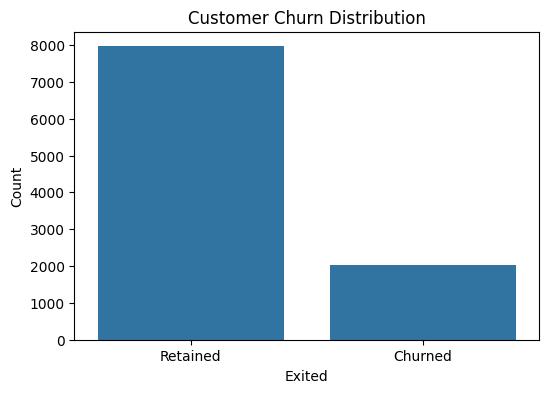

In [29]:
## 1. Target Variable Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited')
plt.ylabel('Count')

plt.xticks([0,1],['Retained','Churned'])

plt.show()

In [30]:
churn_percent = df['Exited'].value_counts(normalize=True)*100
print(churn_percent)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


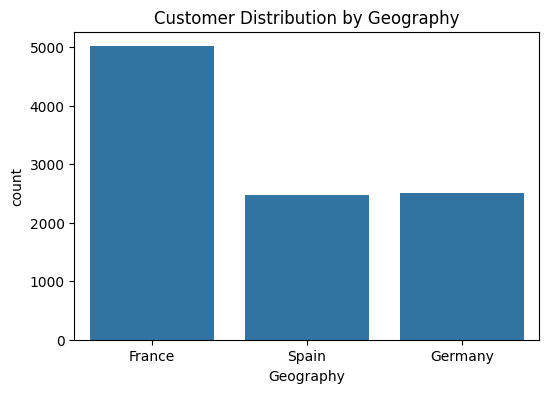

In [31]:
## 2.Geography Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Geography', data=df)

plt.title('Customer Distribution by Geography')

plt.show()


In [32]:
country_percent = df['Geography'].value_counts(normalize=True)*100
print(country_percent)

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


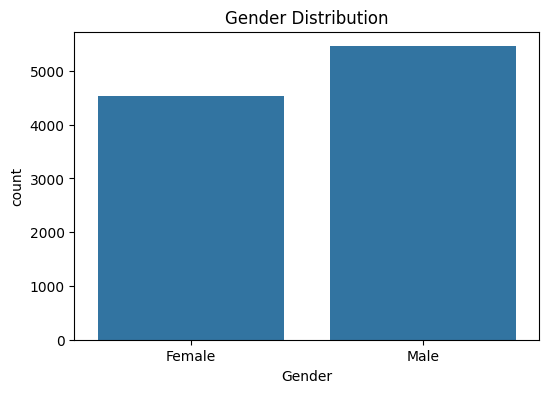

In [33]:
## 3. Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

plt.show()

In [34]:
gender_percent = df['Gender'].value_counts(normalize=True)*100

print(gender_percent)

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64


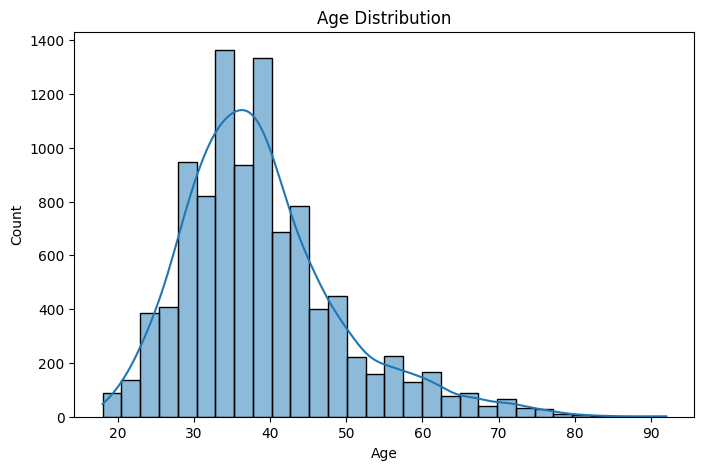

In [35]:
## 4. Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=30,
             kde=True)

plt.title('Age Distribution')

plt.show()

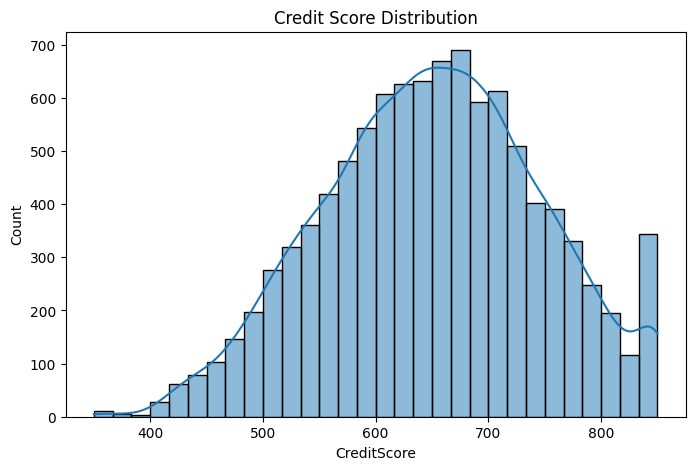

In [36]:
### 5. Credit Score Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['CreditScore'],
             bins=30,
             kde=True)

plt.title('Credit Score Distribution')

plt.show()

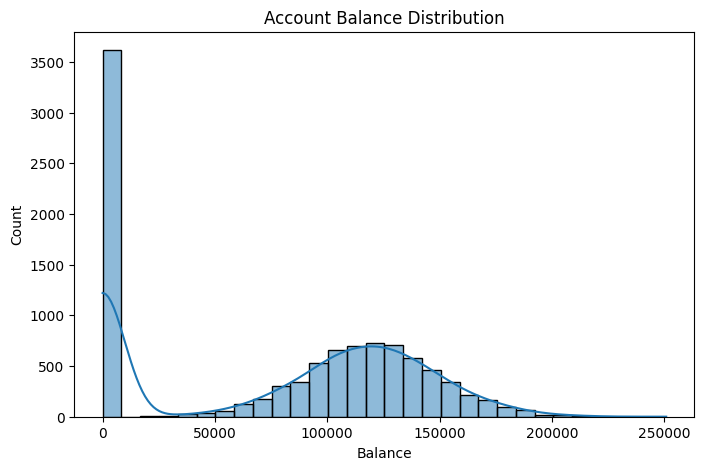

In [37]:
### 6. Balance Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Balance'],
             bins=30,
             kde=True)

plt.title('Account Balance Distribution')

plt.show()

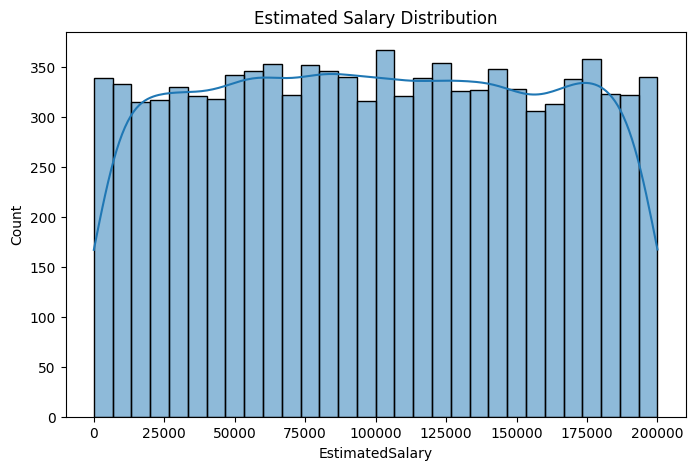

In [38]:
#### 7. Salary Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['EstimatedSalary'],
             bins=30,
             kde=True)

plt.title('Estimated Salary Distribution')

plt.show()

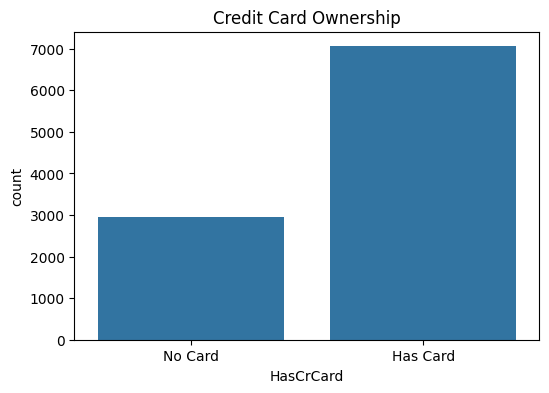

In [39]:
### 8. Credit Card Ownership

plt.figure(figsize=(6,4))

sns.countplot(x='HasCrCard', data=df)

plt.xticks([0,1],['No Card','Has Card'])

plt.title('Credit Card Ownership')

plt.show()

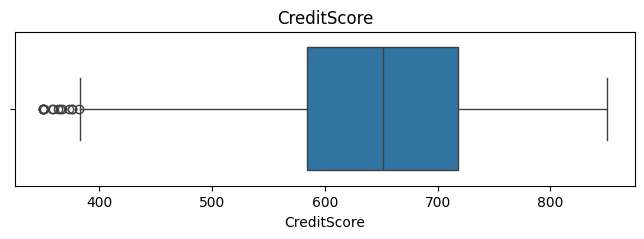

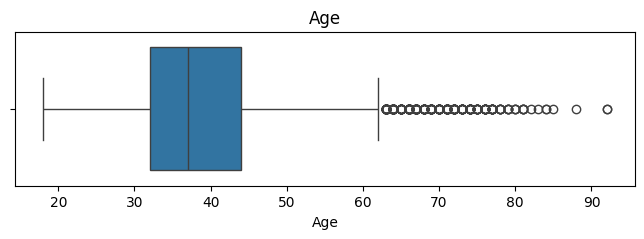

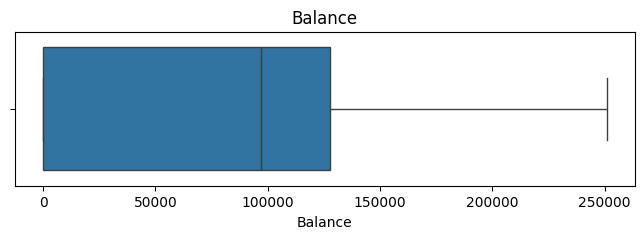

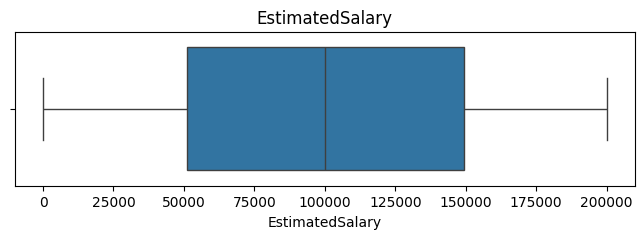

In [40]:
### 9. Numerical Variable Summary

num_cols = ['CreditScore',
            'Age',
            'Balance',
            'EstimatedSalary']

for col in num_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

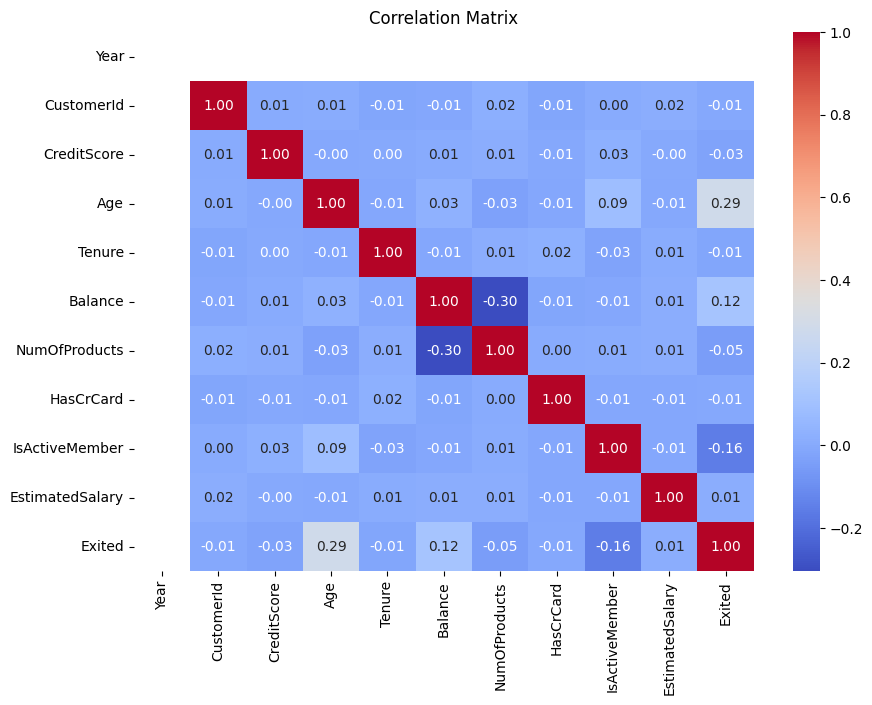

In [41]:
# 10. Correlation Analysis

plt.figure(figsize=(10,7))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')

plt.show()

### Bivariate Analysis (Customer Churn Focus)

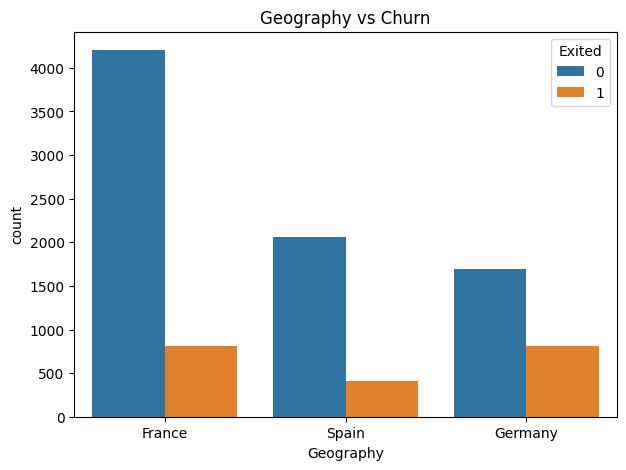

In [42]:
# 1.Geography vs Churn

plt.figure(figsize=(7,5))

sns.countplot( data=df, x= 'Geography' , hue ='Exited')

plt.title('Geography vs Churn')
plt.show()

In [43]:
geo_churn = pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
)*100

geo_churn

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


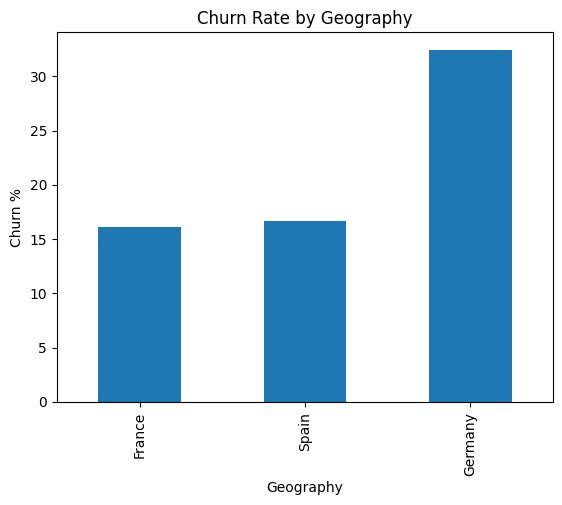

In [44]:
geo_churn[1].sort_values().plot(
    kind='bar'
)

plt.ylabel("Churn %")
plt.title("Churn Rate by Geography")
plt.show()

* Insights:

 Germany shows the highest churn rate among all regions,
indicating customers in Germany are more likely to leave the bank.

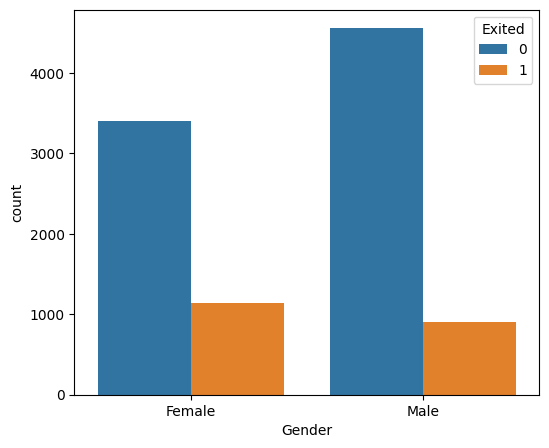

In [45]:
## 2) Gender vs Churn

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender' , hue ='Exited')

plt.show()

In [46]:
gender_churn = pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
)*100

gender_churn

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


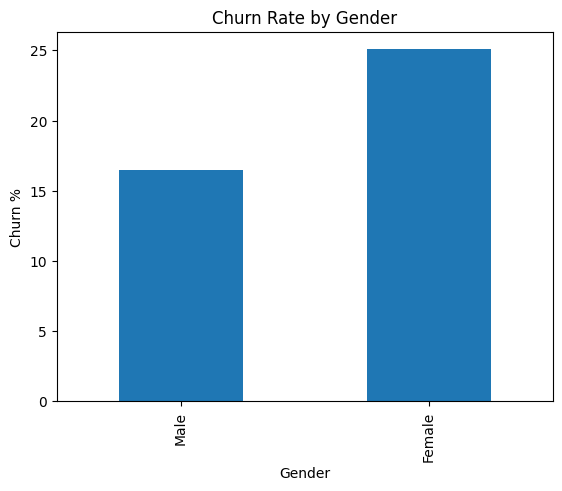

In [47]:
gender_churn[1].sort_values().plot(
    kind='bar'
)

plt.ylabel("Churn %")
plt.title("Churn Rate by Gender")
plt.show()

* Insights:

Female customers show a slightly higher churn rate compared
to male customers.

In [48]:
# 3) Age vs Churn

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,20,30,40,50,60,100],
    labels=[
        '0-20',
        '21-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

df['AgeGroup'].value_counts()

,count
AgeGroup,
31-40,4451
41-50,2320
21-30,1879
51-60,797
60+,464
0-20,89


In [49]:
### Churn Rate by Age Group

age_churn = pd.crosstab(
    df['AgeGroup'],
    df['Exited'],
    normalize='index'
)*100

age_churn

Exited,0,1
AgeGroup,,
0-20,94.382022,5.617978
21-30,92.389569,7.610431
31-40,87.912829,12.087171
41-50,66.034483,33.965517
51-60,43.789210,56.210790
60+,75.215517,24.784483


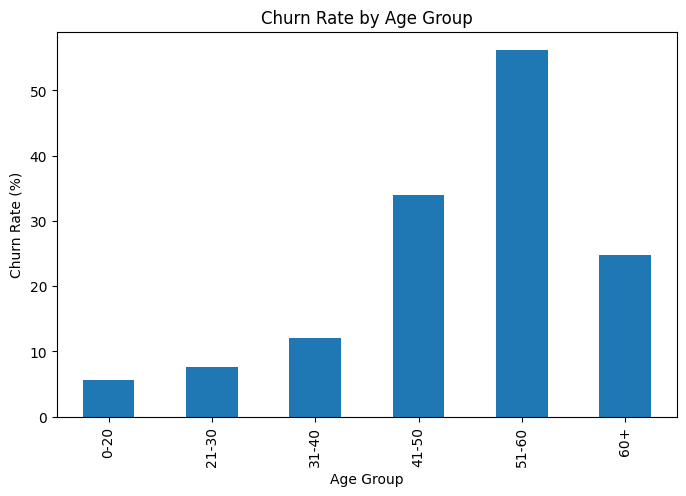

In [50]:
plt.figure(figsize=(8,5))

age_churn[1].plot(
    kind='bar'
)

plt.ylabel('Churn Rate (%)')
plt.xlabel('Age Group')
plt.title('Churn Rate by Age Group')

plt.show()

* Insights :    

Customer churn increases with age. Customers aged 51+ exhibit the highest churn rates, while younger customers show stronger retention. This suggests that retention strategies should focus more heavily on middle-aged and senior customer segments.

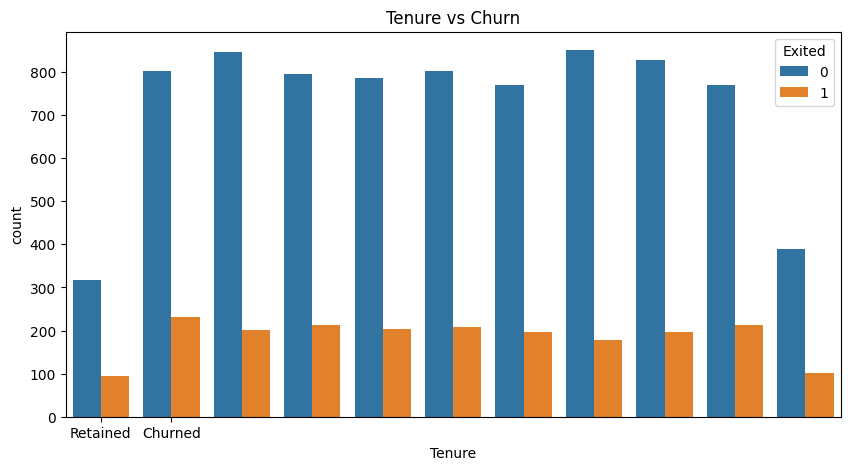

In [51]:
### 4.Tenure vs Churn

plt.figure(figsize=(10,5))

sns.countplot(data=df , x='Tenure', hue='Exited')


plt.xticks([0,1],['Retained','Churned'])

plt.title("Tenure vs Churn")
plt.show()

* Insights :

Tenure alone has a weak impact on churn.

In [52]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup'],
      dtype='object')

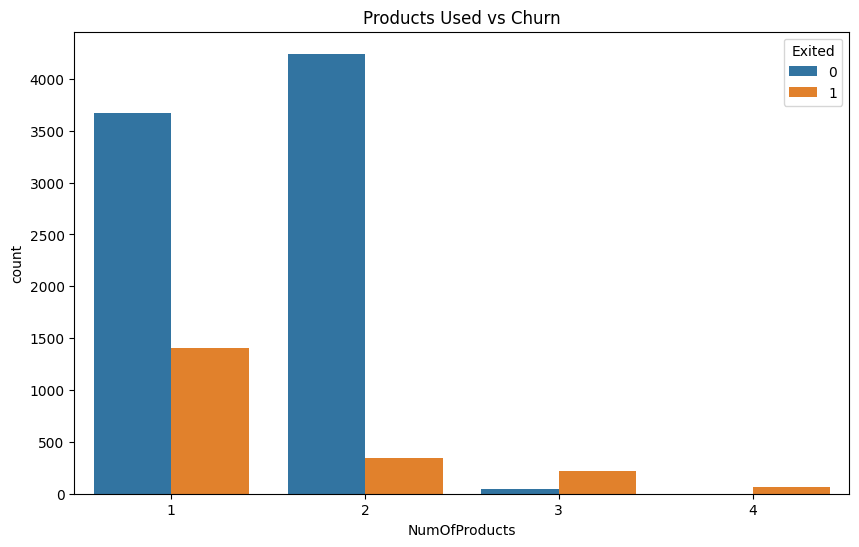

In [53]:
### 5. Number of Products vs Churn

plt.figure(figsize=(10,6))

sns.countplot(data=df,x='NumOfProducts',hue = 'Exited')

plt.title("Products Used vs Churn")
plt.show()

In [54]:
product_churn = pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
)*100

product_churn

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


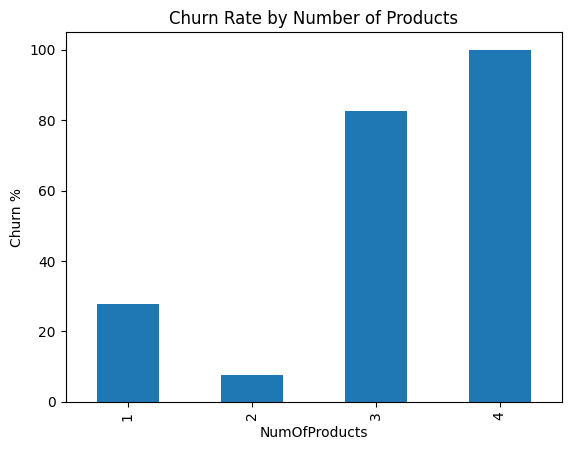

In [55]:
product_churn[1].plot(kind='bar')

plt.ylabel('Churn %')
plt.title('Churn Rate by Number of Products')

plt.show()

* Insights :  
       
Customers using multiple products generally show lower churn,
suggesting stronger relationship depth.




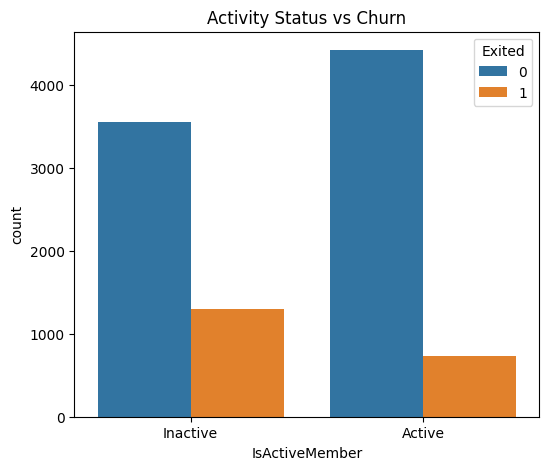

In [56]:
### 6.Active Member vs Churn

plt.figure(figsize=(6,5))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.xticks(
    [0,1],
    ['Inactive','Active']
)

plt.title('Activity Status vs Churn')

plt.show()

In [57]:
activity_churn = pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
)*100

activity_churn

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


* Insights :

Inactive customers exhibit significantly higher churn rates
than active customers.

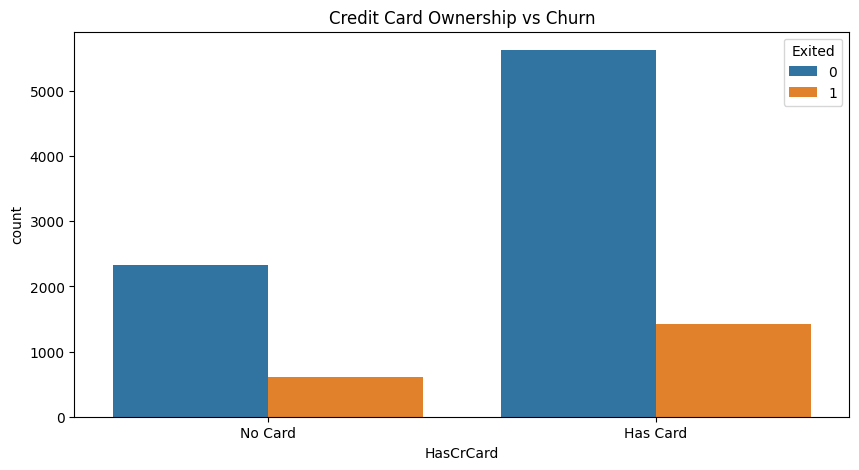

In [58]:
### 7.Credit Card vs Churn

plt.figure(figsize=(10,5))

sns.countplot(
    x='HasCrCard',
    hue='Exited',
    data=df
)

plt.xticks(
    [0,1],
    ['No Card','Has Card']
)

plt.title('Credit Card Ownership vs Churn')

plt.show()

* Insights :     

Credit card ownership has limited influence on customer retention.

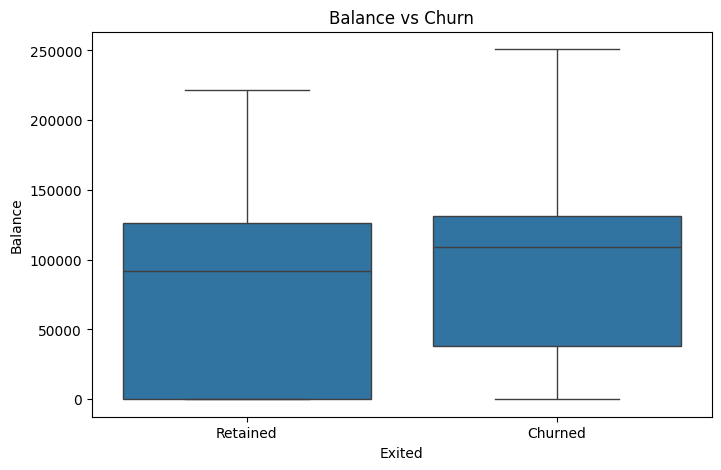

In [59]:
### 7. Balance vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.xticks(
    [0,1],
    ['Retained','Churned']
)

plt.title('Balance vs Churn')

plt.show()

* Insights :      

High balance customers can still churn,
indicating financial value alone does not guarantee loyalty.

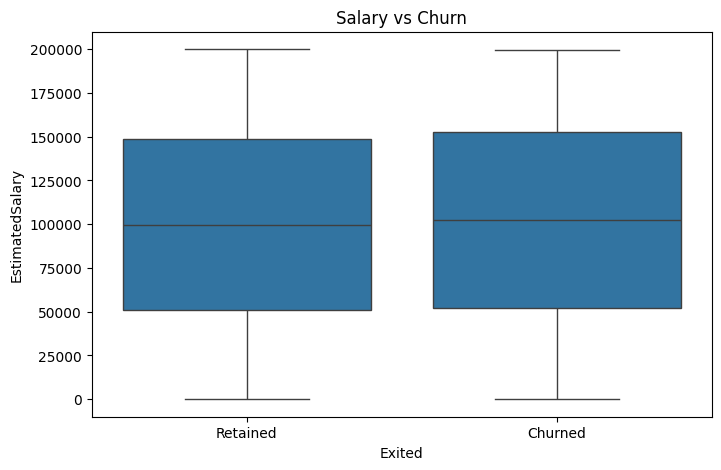

In [60]:
### 8. Salary vs Churn


plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='EstimatedSalary',
    data=df
)

plt.xticks(
    [0,1],
    ['Retained','Churned']
)

plt.title('Salary vs Churn')

plt.show()

* Insights :      

Estimated salary does not appear to have a strong relationship with churn.

### Engagement Profiles

In [61]:
### Engagement Profile Column

In [62]:
conditions = [

    (df['IsActiveMember']==1) &
    (df['NumOfProducts']>=2),

    (df['IsActiveMember']==0) &
    (df['NumOfProducts']<=1),

    (df['IsActiveMember']==1) &
    (df['NumOfProducts']==1),

    (df['IsActiveMember']==0) &
    (df['Balance'] > df['Balance'].median())

]

In [63]:
choices = [

    'Active Engaged',

    'Inactive Disengaged',

    'Active Low Product',

    'Inactive High Balance'

]

In [64]:
df['EngagementProfile'] = np.select(
    conditions,
    choices,
    default='Moderate Engagement'
)

df['EngagementProfile'].head()

,EngagementProfile
0,Active Low Product
1,Active Low Product
2,Inactive High Balance
3,Moderate Engagement
4,Active Low Product


In [65]:
df['EngagementProfile'].value_counts()

,count
EngagementProfile,
Active Engaged,2588
Active Low Product,2563
Inactive Disengaged,2521
Moderate Engagement,1515
Inactive High Balance,813


In [66]:
df['EngagementProfile'].value_counts(normalize=True) *100

,proportion
EngagementProfile,
Active Engaged,25.88
Active Low Product,25.63
Inactive Disengaged,25.21
Moderate Engagement,15.15
Inactive High Balance,8.13


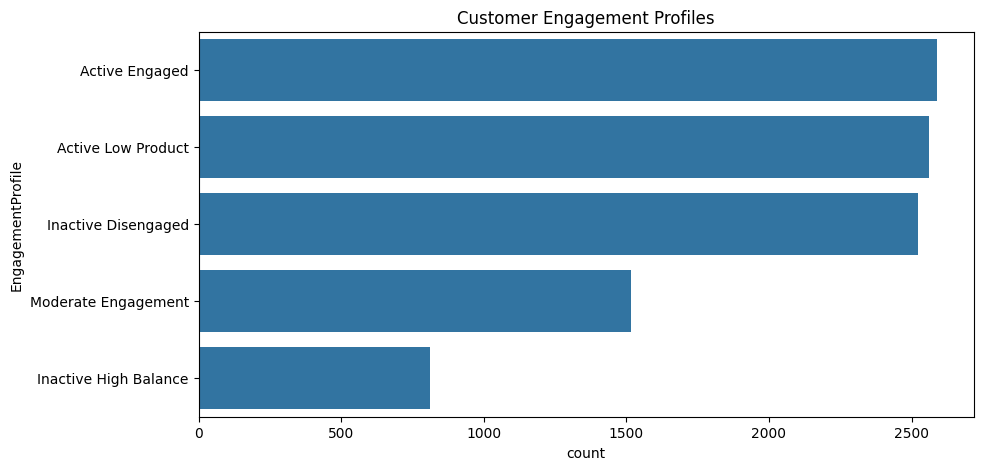

In [67]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='EngagementProfile',
    data=df,
    order=df['EngagementProfile'].value_counts().index
)

plt.title('Customer Engagement Profiles')

plt.show()

In [68]:
#### Engagement Profile vs Churn

engagement_churn = pd.crosstab(
    df['EngagementProfile'],
    df['Exited'],
    normalize='index'
)*100

engagement_churn

Exited,0,1
EngagementProfile,,
Active Engaged,90.340031,9.659969
Active Low Product,81.076863,18.923137
Inactive Disengaged,63.347878,36.652122
Inactive High Balance,72.939729,27.060271
Moderate Engagement,89.570957,10.429043


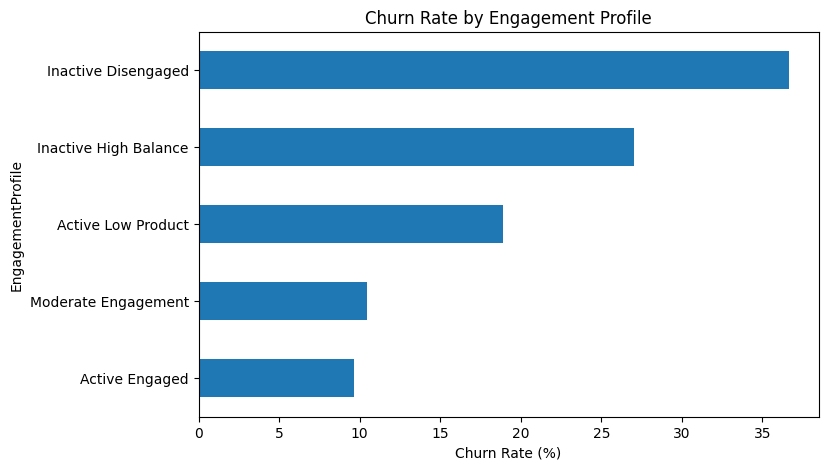

In [69]:
engagement_churn[1].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.xlabel('Churn Rate (%)')

plt.title('Churn Rate by Engagement Profile')

plt.show()

* Insights :     

Active Engaged customers exhibit the lowest churn rates, while Inactive Disengaged and Inactive High Balance customers show significantly elevated churn risk.

In [70]:
#### KPI 1 — Engagement Retention Ratio

active_churn = df[df['IsActiveMember']==1]['Exited'].mean()

inactive_churn = df[df['IsActiveMember']==0]['Exited'].mean()

engagement_retention_ratio = inactive_churn / active_churn

print(f'Active Churn : {active_churn}')
print('---------------')
print(f'Inactive Churn : {inactive_churn}')
print('---------------')
print(f'Engagement Retention Ratio : {engagement_retention_ratio}')


Active Churn : 0.14269073966220153
---------------
Inactive Churn : 0.26850897092183956
---------------
Engagement Retention Ratio : 1.8817547064195856


* Insights :

1) Active Churns are 14.27% .
2) InActive Churns are 26.85% .
3) Inactive customers are approximately 1.88 times more likely to churn than active customers.


In [71]:
### Product Utilization Analysis

In [72]:
# Single Product vs Multi Product


# creating categories

import numpy as np

df['ProductCategory'] = np.where(
    df['NumOfProducts']==1,
    'Single Product',
    'Multi Product'
)

df['ProductCategory'].value_counts(normalize=True)*100

,proportion
ProductCategory,
Single Product,50.84
Multi Product,49.16


In [73]:
###Churn Comparison

product_cat_churn = pd.crosstab(
    df['ProductCategory'],
    df['Exited'],
    normalize='index'
)*100

product_cat_churn

Exited,0,1
ProductCategory,,
Multi Product,87.225386,12.774614
Single Product,72.285602,27.714398


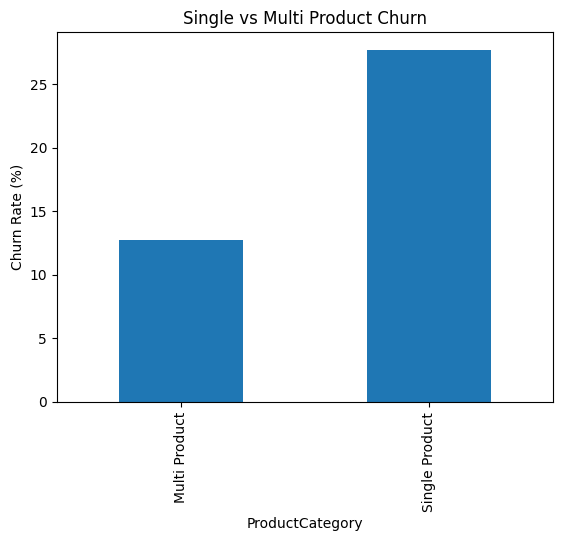

In [74]:
product_cat_churn[1].plot(kind='bar')

plt.ylabel('Churn Rate (%)')

plt.title('Single vs Multi Product Churn')

plt.show()

* Insights :          

Customers using multiple banking products exhibit significantly lower churn rates compared to customers using only a single product. The churn rate for single-product customers is 27.71%, whereas the churn rate for multi-product customers is only 12.77%. This indicates that customers with deeper product relationships are substantially more loyal and less likely to leave the bank.

In [75]:
#### KPI 2 — Product Depth Index


product_depth_index = round(
    df['NumOfProducts'].mean(),
    2
)

print(product_depth_index)

1.53


In [76]:
df['NumOfProducts'].describe()

,NumOfProducts
count,10000.000000
mean,1.530200
std,0.581654
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,4.000000


* Insights :           

Customers use an average of 1.53 banking products.

Lower values indicate cross-selling opportunities.

In [77]:
### High-Value Disengaged Customer Detection

# Find customers who:

# Have high balances
# Have high salaries
# But are not actively engaged

# These are the customers most likely to create "silent churn" problems.

In [78]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup',
       'EngagementProfile', 'ProductCategory'],
      dtype='object')

In [79]:
df['Balance'].dtypes

dtype('float64')

In [80]:
print((df['Balance'] == 0).sum())

3617


In [81]:
df['BalanceSegment'] = pd.cut(
    df['Balance'],
    bins=[
        -1,0,50000,100000,df['Balance'].max()],
    labels=[
        'Zero Balance',
        'Low Value',
        'Medium Value',
        'Premium'
    ])

In [82]:
df['BalanceSegment'].value_counts()

,count
BalanceSegment,
Premium,4799
Zero Balance,3617
Medium Value,1509
Low Value,75


In [83]:
BalanceSegment_churn = pd.crosstab(
    df['BalanceSegment'],
    df['Exited'],
    normalize='index'
)*100

BalanceSegment_churn

Exited,0,1
BalanceSegment,,
Zero Balance,86.176389,13.823611
Low Value,65.333333,34.666667
Medium Value,80.119284,19.880716
Premium,74.765576,25.234424


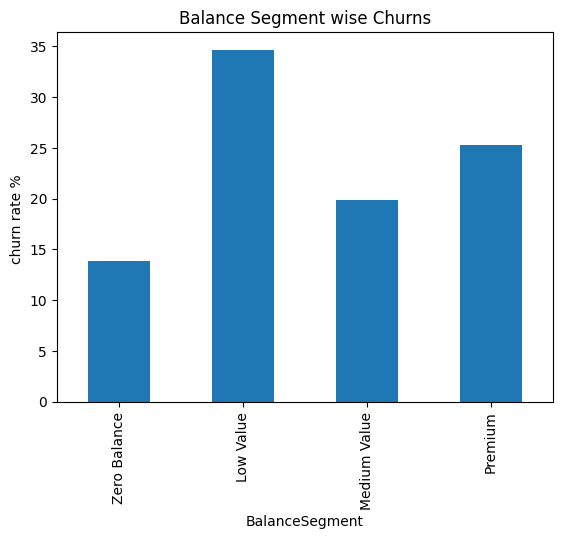

In [84]:
BalanceSegment_churn[1].plot(kind='bar')

plt.ylabel('churn rate % ')

plt.title('Balance Segment wise Churns')
plt.show()

* Insights :  
Customers in the Low Value segment exhibit the highest churn rate (34.67%), making them the most vulnerable customer group. This suggests that customers maintaining small balances may have weaker relationships with the bank and are more likely to switch to competitors.    


In [85]:
#### Premium Customer Segmentation

In [86]:
df['Balance'].describe()

,Balance
count,10000.000000
mean,76485.889288
std,62397.405202
min,0.000000
25%,0.000000
50%,97198.540000
75%,127644.240000
max,250898.090000


In [87]:
premium_threshold = df['Balance'].quantile(0.75)

print(premium_threshold)

127644.24


In [88]:
df['PremiumCustomer'] = np.where(
    df['Balance'] >= premium_threshold,1,0)


print(df['PremiumCustomer'].value_counts())
print('------------------------')
print(df['PremiumCustomer'].value_counts(normalize=True)*100)

PremiumCustomer
0    7500
1    2500
Name: count, dtype: int64
------------------------
PremiumCustomer
0    75.0
1    25.0
Name: proportion, dtype: float64


In [89]:
## At-Risk Premium Customers

at_risk_premium_customers = df[(df['PremiumCustomer']==1) & (df['IsActiveMember']==0)]

at_risk_premium_customers.shape[0]

1247

In [90]:
####  High-Balance Disengagement Rate KPI


premium_total = len(df[df['PremiumCustomer']==1])

at_risk_total = len(at_risk_premium_customers)

high_balance_disengagement_rate = (at_risk_total /premium_total) * 100

zz = round(high_balance_disengagement_rate, 2)

print(f'High-Balance Disengagement Rate KPI : {zz}')

High-Balance Disengagement Rate KPI : 49.88


* Insights :

Approximately 49.88% of premium customers are inactive despite maintaining high balances. These customers contribute significant financial value to the bank but show weak engagement behavior, making them a critical retention priority.

In [91]:
### Salary-Balance Mismatch Detection

# High Salary + Low Balance

In [92]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup',
       'EngagementProfile', 'ProductCategory', 'BalanceSegment',
       'PremiumCustomer'],
      dtype='object')

In [93]:
salary_threshold = (df['EstimatedSalary'].quantile(0.75))

balance_threshold = ( df['Balance'].quantile(0.25))

print(salary_threshold)
print(balance_threshold)


149388.2475
0.0


In [94]:
df[['EstimatedSalary','Balance']].describe()

,EstimatedSalary,Balance
count,10000.000000,10000.000000
mean,100090.239881,76485.889288
std,57510.492818,62397.405202
min,11.580000,0.000000
25%,51002.110000,0.000000
50%,100193.915000,97198.540000
75%,149388.247500,127644.240000
max,199992.480000,250898.090000


In [95]:
salary_balance_mismatch = df[(df['EstimatedSalary'] >= salary_threshold) & (df['Balance'] <= balance_threshold)]

salary_balance_mismatch.shape[0]

891

* Insights :              

There Are 891 customers who has salary above the threshold amount but maintain balance below the threshold amount.

In [96]:
### Creating Mismatch Flag

df['SalaryBalanceMismatch'] = np.where((df['EstimatedSalary'] >= salary_threshold) & (df['Balance'] <= balance_threshold), 1, 0)

df['SalaryBalanceMismatch'].value_counts()

,count
SalaryBalanceMismatch,
0,9109
1,891


In [97]:
### Churn Among Mismatch Customers
mismatch_churn = pd.crosstab(df['SalaryBalanceMismatch'],df['Exited'],
    normalize='index')*100

mismatch_churn

Exited,0,1
SalaryBalanceMismatch,,
0,79.086618,20.913382
1,85.185185,14.814815


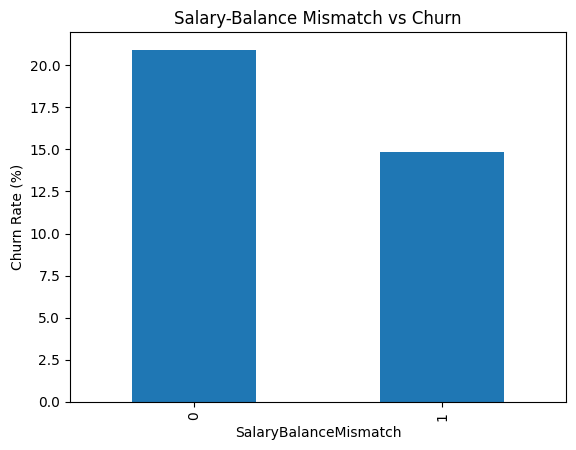

In [98]:
mismatch_churn[1].plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Salary-Balance Mismatch vs Churn')

plt.show()

* Insights :                 

Customers with a Salary-Balance Mismatch exhibit a lower churn rate (14.81%) compared to customers without a mismatch (20.91%).

That Means :  High-income customers who maintain relatively low balances are not necessarily leaving the bank.

### Premium Customer Risk Dashboard Table

In [99]:
### Premium Customer Risk Dashboard Table


premium_summary = pd.DataFrame({'Metric': ['Total Premium Customers','At Risk Premium Customers','High Balance Disengagement Rate'],

                                'Value': [premium_total, at_risk_total, round(high_balance_disengagement_rate,2)]})

premium_summary

,Metric,Value
0,Total Premium Customers,2500.00
1,At Risk Premium Customers,1247.00
2,High Balance Disengagement Rate,49.88


In [100]:
print(f'Premium Customers : {premium_total}')
print('-----------------')
print(f'At Risk Premium Customers : {at_risk_total}')
print('-----------------')
print(f'High Balance Disengagment Rate :{high_balance_disengagement_rate}')
print('-----------------')
print(f'Customers with High Salary and Low Balance : {salary_balance_mismatch.shape[0]}')
print('-----------------')
print(mismatch_churn)

Premium Customers : 2500
-----------------
At Risk Premium Customers : 1247
-----------------
High Balance Disengagment Rate :49.88
-----------------
Customers with High Salary and Low Balance : 891
-----------------
Exited                         0          1
SalaryBalanceMismatch                      
0                      79.086618  20.913382
1                      85.185185  14.814815


* Insights :                      

1. **Premium Customer Risk**

The bank has 2,500 premium customers, representing the top balance holders. However, 1,247 of these customers are inactive, resulting in a High-Balance Disengagement Rate of 49.88%.

2. **High Balance Does Not Guarantee Loyalty**

Despite maintaining high account balances, nearly 50% of premium customers exhibit low engagement levels. This finding confirms that financial commitment alone is insufficient to ensure customer retention.

3. **Silent Churn Risk**

Inactive premium customers represent the highest-value churn risk segment. These customers may not have exited yet, but their low engagement levels indicate a higher probability of future attrition.

4. **Salary-Balance Mismatch Customers**

The analysis identified 891 customers with high salaries but relatively low account balances.

5. **Unexpected Churn Behavior**


No Mismatch	-  20.91%

Mismatch	 -   14.81%

Contrary to expectations, Salary-Balance Mismatch customers exhibit lower churn rates than other customers.

## Conclusion :

The High-Value Customer Analysis reveals that customer engagement is a stronger predictor of retention than financial value alone. Nearly half of all premium customers are inactive, indicating substantial silent churn risk despite high balances. Additionally, high-income customers with low balances demonstrate relatively strong retention, suggesting opportunities for cross-selling and wealth management rather than traditional retention interventions. The findings highlight the importance of engagement-driven retention strategies, proactive relationship management, and targeted product expansion programs.